## Exercice 2



In [12]:
import numpy as np
import matplotlib.pyplot as plt


# Experimental data
p_gL = np.array([0.0, 12.0, 39.0, 55.0])  # lactic acid concentration (g/L)
mu = np.array([0.9, 0.68, 0.52, 0.13])    # specific growth rate (h^-1)

mu_max = mu[0]

# Constants
pH = 6.3
pKa = 3.88
Mw = 90.08  # g/mol


a) Relative specific growth rate vs undissociated acid concentration

Lactic acid is a weak acid that partially dissociates in water:

$$
HA \rightleftharpoons H^+ + A^-
$$

Only the undissociated form ($HA$) is able to diffuse through the bacterial membrane and exert a toxic effect on the cells.

The relationship between the dissociated and undissociated forms is given by the Henderson–Hasselbalch equation:

$$
pH = pK_a + \log_{10}\left(\frac{[A^-]}{[HA]}\right)
$$

From this equation, the fraction of undissociated acid can be written as:

$$
\text{fraction} = \frac{1}{1 + 10^{(pH - pK_a)}}
$$

The concentration of undissociated acid $P$ is therefore:

$$
P = C_{\text{total}} \times \text{fraction}
$$

where:
C_total is the total lactic acid concentration and P is the concentration of undissociated acid

Finally, the relative growth rate is computed as:
$$
μ / μ₀
$$

where μ₀ is the growth rate measured at zero lactic acid concentration.

Undissociated acid concentration (mM):
[0.         0.50455075 1.63978994 2.31252428]


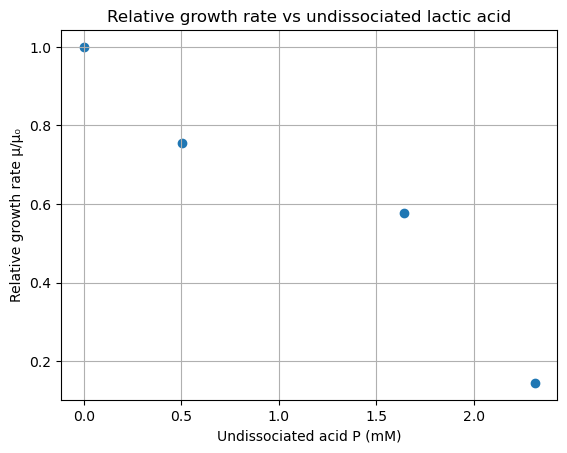

In [13]:
C_total = p_gL / Mw # Convert total concentration to mol/L

# Fraction of undissociated acid
fraction = 1 / (1 + 10**(pH - pKa))

# Undissociated acid concentration in mM
P = C_total * fraction * 1000

# Relative growth rate
mu_rel = mu / mu_max

print("Undissociated acid concentration (mM):")
print(P)

plt.scatter(P, mu_rel)
plt.xlabel("Undissociated acid P (mM)")
plt.ylabel("Relative growth rate μ/μ₀")
plt.title("Relative growth rate vs undissociated lactic acid")
plt.grid()
plt.show()

b) Determination of the inhibition constant $K_I$

The inhibition kinetics are assumed to follow the equation:

$$
\mu = \mu_{max} \cdot \left(\frac{S}{K_M + S}\right) \cdot \left(\frac{1}{1 + P/K_I}\right)
$$

Because the experiment was performed under substrate saturation, the substrate concentration is much larger than $K_M$:

$$
S \gg K_M
$$

Therefore:

$$
\frac{S}{K_M + S} \approx 1
$$

and the equation simplifies to:

$$
\mu = \frac{\mu_{max}}{1 + P/K_I}
$$

This also explains why:

$$
\mu(P = 0) = \mu_{max}
$$

since no inhibition occurs when the undissociated acid concentration is zero.

To estimate $K_I$, the equation can be linearized:

$$
\frac{1}{\mu} = \frac{1}{\mu_{max}} + \frac{P}{\mu_{max} K_I}
$$

In [14]:
# Linearization
y = 1/mu - 1/mu_max
x = P

slope = np.polyfit(x, y, 1)[0]

KI = 1/(slope * mu_max)

print("Estimated inhibition constant KI (mM):", KI)

Estimated inhibition constant KI (mM): 0.45649531875163263


Result

Using the linear regression, the inhibition constant is estimated to be:
$$
KI ≈ 0.46 mM
$$

This value represents the concentration of undissociated acid that significantly reduces the bacterial growth rate.

c) Alternative inhibition model

An alternative inhibition model is proposed:

$$
\mu = \mu_{max} \cdot \left(\frac{S}{K_M + S}\right) \cdot \left(1 - \frac{P}{P_{max}}\right)
$$

Again, under substrate saturation:

$$
\mu = \mu_{max} \left(1 - \frac{P}{P_{max}}\right)
$$

In this model, the parameter $P_{max}$ represents the maximum concentration of undissociated acid at which growth completely stops.

The model can be rewritten as a linear relationship:

$$
\mu = \mu_{max} - \left(\frac{\mu_{max}}{P_{max}}\right) P
$$

Therefore, $P_{max}$ can be estimated using a linear regression between $\mu$ and $P$.

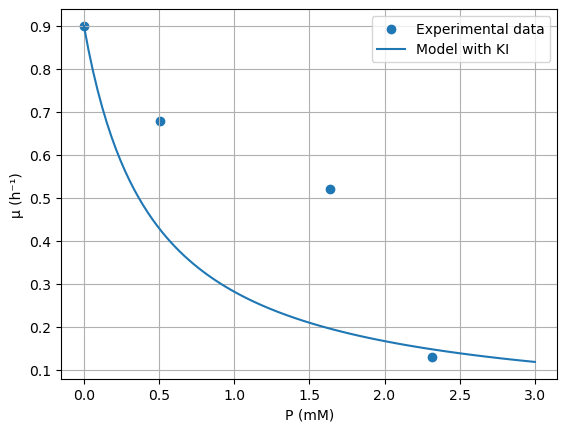

In [15]:
P_range = np.linspace(0,3,100)

mu_model1 = mu_max / (1 + P_range/KI)

plt.scatter(P, mu, label="Experimental data")
plt.plot(P_range, mu_model1, label="Model with KI")
plt.xlabel("P (mM)")
plt.ylabel("μ (h⁻¹)")
plt.legend()
plt.grid()
plt.show()

In [16]:
coef = np.polyfit(P, mu, 1)

slope = coef[0]
intercept = coef[1]

Pmax = -mu_max/slope

print("Estimated Pmax (mM):", Pmax)

Estimated Pmax (mM): 3.0282704673059233


Comparison of the two inhibition models

To determine which model best describes the experimental data, both models are compared with the measurements.

A quantitative comparison is performed using the Sum of Squared Errors (SSE):

$$
SSE = \sum (\mu_{exp} - \mu_{model})^2
$$

The model with the lowest SSE provides the best fit to the experimental data.

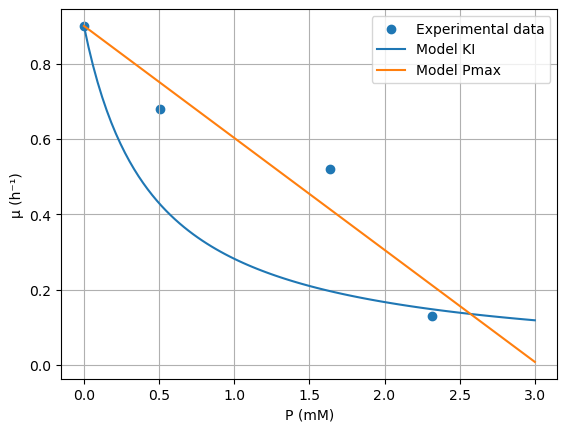

In [17]:
mu_model2 = mu_max * (1 - P_range/Pmax)

plt.scatter(P, mu, label="Experimental data")
plt.plot(P_range, mu_model1, label="Model KI")
plt.plot(P_range, mu_model2, label="Model Pmax")
plt.xlabel("P (mM)")
plt.ylabel("μ (h⁻¹)")
plt.legend()
plt.grid()
plt.show()

In [18]:
mu_pred1 = mu_max/(1+P/KI)
mu_pred2 = mu_max*(1-P/Pmax)

sse1 = np.sum((mu-mu_pred1)**2)
sse2 = np.sum((mu-mu_pred2)**2)

print("SSE model KI:", sse1)
print("SSE model Pmax:", sse2)

SSE model KI: 0.16907860694218912
SSE model Pmax: 0.02327202432280495


The Pmax model gives a significantly lower SSE compared to the KI model.

This indicates that the linear inhibition model better represents the experimental data.

Biologically, this model is also meaningful because it predicts a critical undissociated acid concentration at which bacterial growth completely stops.

Therefore, the Pmax model will be used for the following analysis.

d) Effect of pH on bacterial growth

The concentration of undissociated acid depends strongly on pH according to:

$$
P = \frac{C_{total}}{1 + 10^{(pH - pK_a)}}
$$

Two different total lactic acid concentrations are considered:  
1 g/L and 10 g/L.

Using the inhibition model selected in part (c):

$$
\frac{\mu}{\mu_{max}} = 1 - \frac{P}{P_{max}}
$$

In [19]:
pH_range = np.linspace(3,7,200)

def undissociated(p_gL, pH):
    
    C = p_gL/Mw
    
    return (C/(1+10**(pH-pKa)))*1000

P1 = undissociated(1, pH_range)
P10 = undissociated(10, pH_range)

mu_rel1 = 1 - P1/Pmax
mu_rel10 = 1 - P10/Pmax

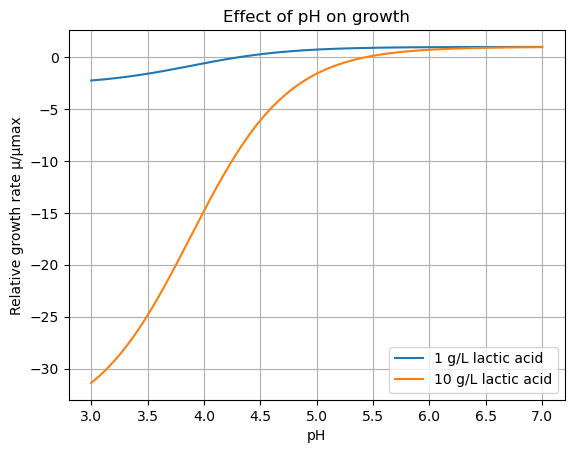

In [20]:
plt.plot(pH_range, mu_rel1, label="1 g/L lactic acid")
plt.plot(pH_range, mu_rel10, label="10 g/L lactic acid")

plt.xlabel("pH")
plt.ylabel("Relative growth rate μ/μmax")
plt.title("Effect of pH on growth")
plt.legend()
plt.grid()

plt.show()

Interpretation

The results show that decreasing the pH increases the fraction of undissociated lactic acid, which increases its inhibitory effect.

At higher total lactic acid concentrations, growth inhibition occurs at higher pH values, because sufficient undissociated acid is present to affect the cells.

This highlights the importance of both total acid concentration and pH in controlling microbial growth.